# ML4SCI Genie — GSoC 2026 Evaluation Tasks

**Dataset:** Quark/Gluon jet events (3 channels: ECAL, HCAL, Tracks — each 125×125)

| Task | Description |
|------|-------------|
| Common Task 1 | Auto-encoder for quark/gluon jet images |
| Common Task 2 | Graph Neural Network (GNN) classifier |
| Specific Task 3 | Diffusion Network for jet event generation |

---

## 0. Environment Setup

In [2]:
# !pip install torch torchvision --quiet
# !pip install torch-geometric --quiet
# !pip install h5py scikit-learn matplotlib seaborn tqdm scipy scikit-image --quiet
# !pip install scikit-image
# !pip install torch-cluster

  Using cached torch_cluster-1.6.3.tar.gz (54 kB)
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'torch-cluster' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'torch-cluster'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for torch-cluster: filename=torch_cluster-1.6.3-cp310-cp310-macosx_11_0_arm64.whl size=292350 sha256=5967d854ff603e75e84af42073a3ff3bad23fd76810a0c8f75748d657c7ed0ee
  Stored in directory: /Users/aditya/Library/Caches/pip/wheels/51/78/c3/536637b3cdcc3313aa5e8851a6c72b97f6a01877e68c7595e3
Successfully built torch-cluster


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import h5py, os, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.data import DataLoader as GeoLoader
from torch_geometric.nn import (
    DynamicEdgeConv, global_max_pool, global_mean_pool
)

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.neighbors import NearestNeighbors
from scipy import linalg
from skimage.metrics import structural_similarity as ssim_fn
from tqdm import tqdm

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}  |  PyG: {torch_geometric.__version__}')

Device : cpu
PyTorch: 2.10.0  |  PyG: 2.7.0


## 1. Data Loading

In [16]:
DATA_PATH = 'data/quark-gluon_data-set_n139306.hdf5'   # update path if needed

def make_synthetic_data(n=4000):
    np.random.seed(SEED)
    X = np.zeros((n, 125, 125, 3), dtype=np.float32)
    y = np.random.randint(0, 2, n)
    for i in range(n):
        cx, cy = np.random.randint(40, 85, 2)
        for _ in range(np.random.randint(5, 40)):
            dx = int(np.random.normal(0, 8))
            dy = int(np.random.normal(0, 8))
            px, py = np.clip(cx+dx,0,124), np.clip(cy+dy,0,124)
            X[i, px, py, np.random.choice([0,1,2], p=[0.5,0.3,0.2])] += np.random.exponential(0.5)
    return X, y

if os.path.exists(DATA_PATH):
    with h5py.File(DATA_PATH, 'r') as f:
        print('HDF5 keys:', list(f.keys()))
        X_all = f['X_jets'][:].astype(np.float32)   # (N,125,125,3)
        y_all = f['y'][:].astype(np.int64)
    print(f'Real data loaded: {X_all.shape}')
    SYNTHETIC = False
else:
    print(f'[WARNING] {DATA_PATH} not found — using synthetic data.')
    X_all, y_all = make_synthetic_data(4000)
    SYNTHETIC = True

# Normalise each channel to [0,1]
for c in range(3):
    vmax = X_all[..., c].max()
    if vmax > 0:
        X_all[..., c] /= vmax

X_pt = np.transpose(X_all, (0, 3, 1, 2))   # (N,3,125,125) for PyTorch
N_TOTAL = len(X_pt)
label_names = {0: 'Gluon', 1: 'Quark'}
ch_labels   = ['ECAL', 'HCAL', 'Tracks']
print(f'Total: {N_TOTAL} | Quark: {(y_all==1).sum()} | Gluon: {(y_all==0).sum()}')

HDF5 keys: ['X_jets', 'm0', 'pt', 'y']
Real data loaded: (139306, 125, 125, 3)
Total: 139306 | Quark: 69653 | Gluon: 69653


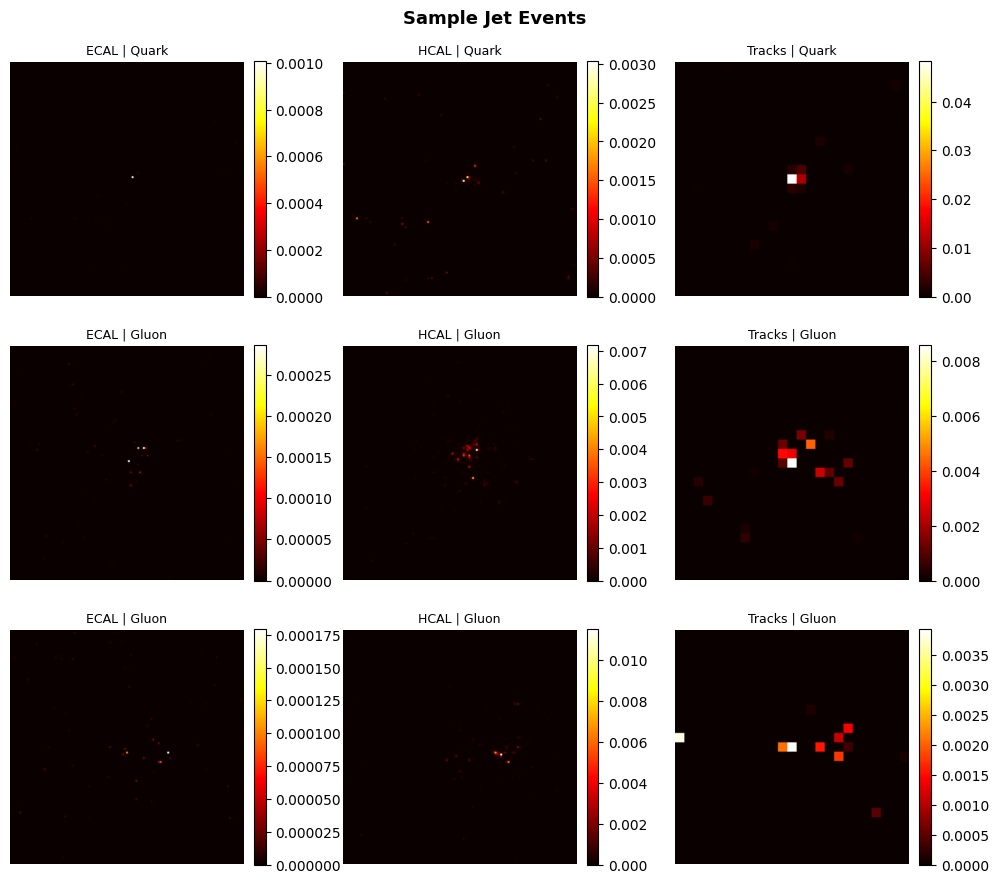

In [17]:
# Sample event visualisation
fig, axes = plt.subplots(3, 3, figsize=(10, 9))
fig.suptitle('Sample Jet Events', fontsize=13, fontweight='bold')
for row in range(3):
    idx = np.random.randint(N_TOTAL)
    for col, ch in enumerate(ch_labels):
        ax = axes[row, col]
        im = ax.imshow(X_all[idx, :, :, col], cmap='hot')
        ax.set_title(f'{ch} | {label_names[y_all[idx]]}', fontsize=9)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('sample_events.png', dpi=100, bbox_inches='tight')
plt.show()

---
# Common Task 1 — Convolutional Auto-Encoder

Architecture: symmetric encoder–decoder with skip-free bottleneck to force learned compression.

In [18]:
class JetImageDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.images)
    def __getitem__(self, idx): return self.images[idx], self.labels[idx]

full_ds = JetImageDataset(X_pt, y_all)
n_train = int(0.8 * N_TOTAL)
train_ds, val_ds = random_split(full_ds, [n_train, N_TOTAL - n_train],
                                generator=torch.Generator().manual_seed(SEED))

BATCH = 64
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0)
print(f'AE Train: {len(train_ds)} | Val: {len(val_ds)}')

AE Train: 111444 | Val: 27862


In [10]:
class ConvAE(nn.Module):
    """Convolutional Auto-Encoder — 3×125×125 jet images."""
    def __init__(self, latent_dim=256):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3,  16, 3, padding=1), nn.BatchNorm2d(16),  nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4)),
            nn.Flatten(),
            nn.Linear(128*4*4, latent_dim), nn.ReLU()
        )
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 128*8*8), nn.ReLU()
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.ConvTranspose2d(64,  32, 4, stride=2, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.ConvTranspose2d(32,  16, 4, stride=2, padding=1), nn.BatchNorm2d(16),  nn.ReLU(),
            nn.ConvTranspose2d(16,   8, 4, stride=2, padding=1), nn.BatchNorm2d(8),   nn.ReLU(),
            nn.Conv2d(8, 3, 3, padding=1),
            nn.AdaptiveAvgPool2d((125,125)),
            nn.Sigmoid()
        )

    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder_conv(self.decoder_fc(z).view(-1,128,8,8))
    def forward(self, x): return self.decode(self.encode(x))

ae_model = ConvAE(latent_dim=256).to(DEVICE)
print(f'ConvAE params: {sum(p.numel() for p in ae_model.parameters()):,}')

ConvAE params: 2,902,467


In [ ]:
# ── Training with ──────────────────────────────────────────────
AE_EPOCHS   = 3

optimizer_ae  = torch.optim.Adam(ae_model.parameters(), lr=1e-3)
scheduler_ae  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_ae, T_max=AE_EPOCHS)

ae_train_losses, ae_val_losses = [], []
best_val_mse = float('inf')
patience_ctr = 0

for epoch in tqdm(range(1, AE_EPOCHS+1), desc='AE Training', unit='epoch'):
    ae_model.train()
    t_loss = 0
    for step, (imgs, _) in enumerate(train_loader):
        imgs  = imgs.to(DEVICE)
        recon = ae_model(imgs)
        loss  = F.mse_loss(recon, imgs)
        optimizer_ae.zero_grad(); loss.backward(); optimizer_ae.step()
        t_loss += loss.item() * len(imgs)
        if (step+1) % 50 == 0:
            print(f'  Epoch {epoch} | Step {step+1}/{len(train_loader)} | Batch Loss: {loss.item():.5f}')
    t_loss /= len(train_ds)

    ae_model.eval()
    v_loss = 0
    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs  = imgs.to(DEVICE)
            recon = ae_model(imgs)
            v_loss += F.mse_loss(recon, imgs).item() * len(imgs)
    v_loss /= len(val_ds)
    scheduler_ae.step()

    ae_train_losses.append(t_loss)
    ae_val_losses.append(v_loss)
    print(f'Epoch {epoch:3d}/{AE_EPOCHS} | Train MSE: {t_loss:.5f} | Val MSE: {v_loss:.5f}')

    # Early stopping
    if v_loss < best_val_mse - 1e-7:
        best_val_mse = v_loss
        patience_ctr = 0
        torch.save(ae_model.state_dict(), 'model/ae_model_best_v2.pt')
        print(f'New best Val MSE: {best_val_mse:.5f} — model saved.')
    

# Load best weights
ae_model.load_state_dict(torch.load('model/ae_model_best.pt', map_location=DEVICE))
print(f'\nFinal best Val MSE: {best_val_mse:.5f}')

  Epoch 1 | Step 50/1742 | Batch Loss: 0.06572
  Epoch 1 | Step 100/1742 | Batch Loss: 0.00672
  Epoch 1 | Step 150/1742 | Batch Loss: 0.00260
  Epoch 1 | Step 200/1742 | Batch Loss: 0.00166
  Epoch 1 | Step 250/1742 | Batch Loss: 0.00116
  Epoch 1 | Step 300/1742 | Batch Loss: 0.00076
  Epoch 1 | Step 350/1742 | Batch Loss: 0.00069
  Epoch 1 | Step 400/1742 | Batch Loss: 0.00045
  Epoch 1 | Step 450/1742 | Batch Loss: 0.00037
  Epoch 1 | Step 500/1742 | Batch Loss: 0.00032
  Epoch 1 | Step 550/1742 | Batch Loss: 0.00040
  Epoch 1 | Step 600/1742 | Batch Loss: 0.00022
  Epoch 1 | Step 650/1742 | Batch Loss: 0.00019
  Epoch 1 | Step 700/1742 | Batch Loss: 0.00017
  Epoch 1 | Step 750/1742 | Batch Loss: 0.00015
  Epoch 1 | Step 800/1742 | Batch Loss: 0.00013
  Epoch 1 | Step 850/1742 | Batch Loss: 0.00012
  Epoch 1 | Step 900/1742 | Batch Loss: 0.00011
  Epoch 1 | Step 950/1742 | Batch Loss: 0.00009
  Epoch 1 | Step 1000/1742 | Batch Loss: 0.00009
  Epoch 1 | Step 1050/1742 | Batch Loss:

In [12]:
# Load best weights
ae_model.load_state_dict(torch.load('model/ae_model_best.pt', map_location=DEVICE))
print(f'\nFinal best Val MSE: {best_val_mse:.5f}')


Final best Val MSE: 0.00001


In [13]:
# load model from disk
# ae_model = torch.load('model/ae_model_best.pt', map_location=DEVICE)

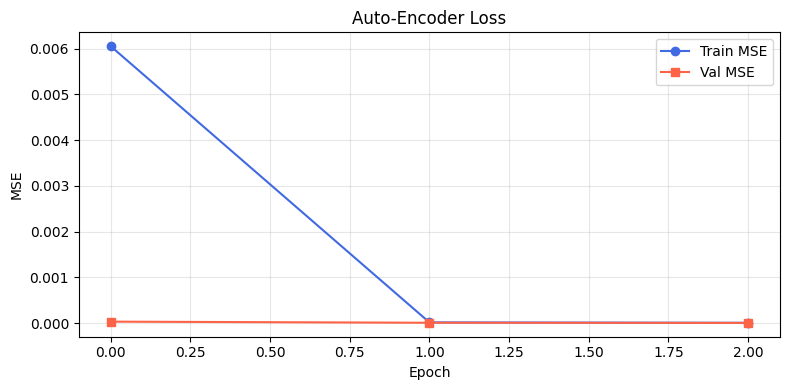

In [14]:
# Loss curve
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(ae_train_losses, label='Train MSE', color='royalblue', marker='o')
ax.plot(ae_val_losses,   label='Val MSE',   color='tomato',    marker='s')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE'); ax.set_title('Auto-Encoder Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ae_loss.png', dpi=100, bbox_inches='tight')
plt.show()

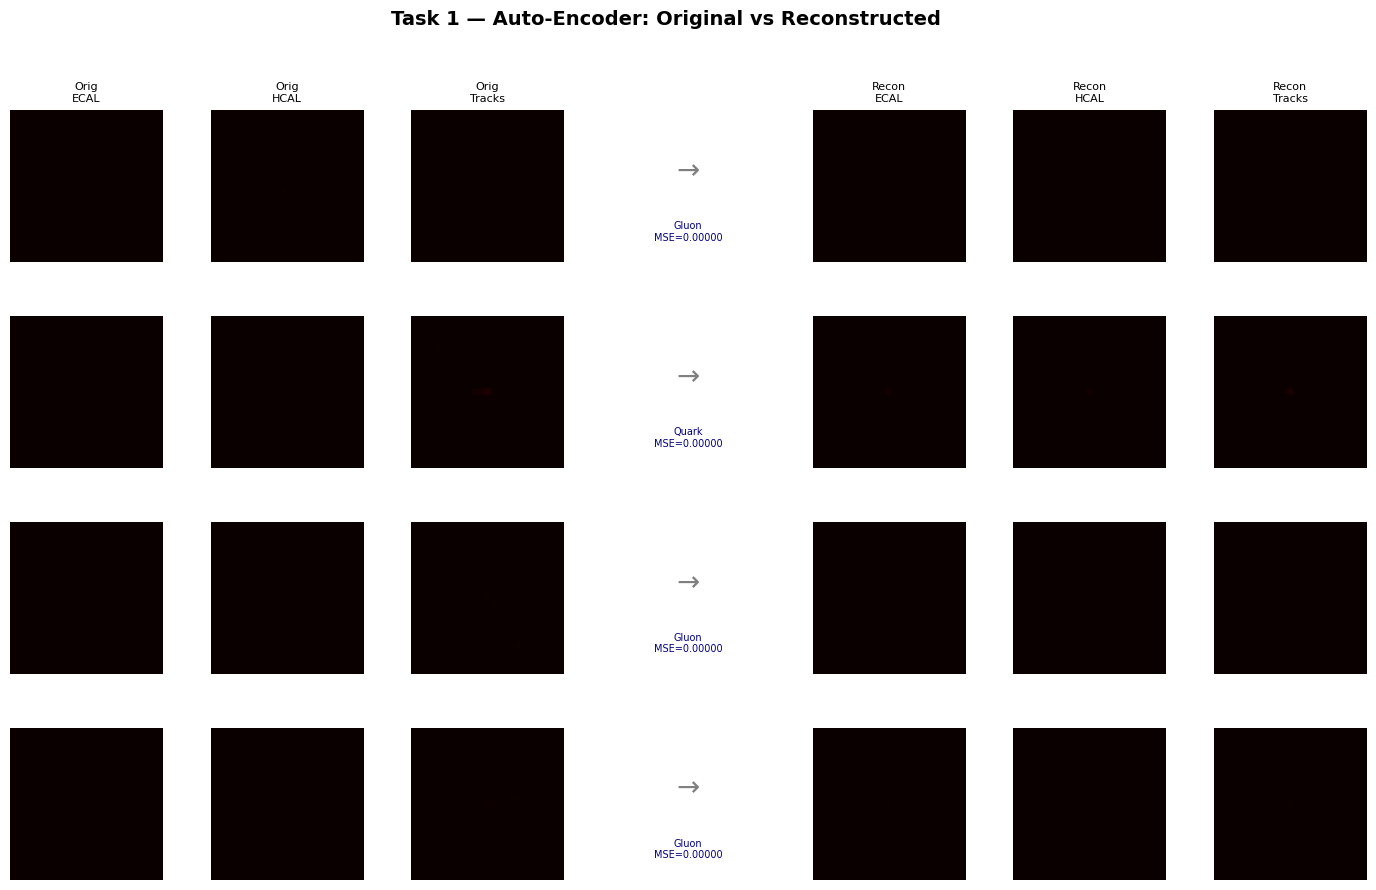

  ECAL   MSE: 0.000000
  HCAL   MSE: 0.000000
  Tracks MSE: 0.000000


In [37]:
# Side-by-side: Original vs Reconstructed
ae_model.eval()
sample_imgs, sample_labels = next(iter(val_loader))
with torch.no_grad():
    recons = ae_model(sample_imgs.to(DEVICE)).cpu()

n_show = 4
fig = plt.figure(figsize=(18, 10))
fig.suptitle('Task 1 — Auto-Encoder: Original vs Reconstructed', fontsize=14, fontweight='bold')
gs  = gridspec.GridSpec(n_show, 7, figure=fig, wspace=0.05, hspace=0.35)

for row in range(n_show):
    orig  = sample_imgs[row].numpy().transpose(1,2,0)
    rec   = recons[row].numpy().transpose(1,2,0)
    mse_v = float(np.mean((orig - rec)**2))
    label = label_names[sample_labels[row].item()]

    for c in range(3):
        ax = fig.add_subplot(gs[row, c])
        ax.imshow(orig[:,:,c], cmap='hot', vmin=0, vmax=1)
        if row == 0: ax.set_title(f'Orig\n{ch_labels[c]}', fontsize=8)
        ax.axis('off')

    ax_sep = fig.add_subplot(gs[row, 3])
    ax_sep.text(0.5, 0.6, '→', ha='center', va='center', fontsize=20, color='gray')
    ax_sep.text(0.5, 0.2, f'{label}\nMSE={mse_v:.5f}',
                ha='center', va='center', fontsize=7, color='navy')
    ax_sep.axis('off')

    for c in range(3):
        ax = fig.add_subplot(gs[row, 4+c])
        ax.imshow(rec[:,:,c], cmap='hot', vmin=0, vmax=1)
        if row == 0: ax.set_title(f'Recon\n{ch_labels[c]}', fontsize=8)
        ax.axis('off')

plt.savefig('ae_comparison.png', dpi=110, bbox_inches='tight')
plt.show()

# Per-channel MSE
for c, ch in enumerate(ch_labels):
    print(f'  {ch:6s} MSE: {F.mse_loss(recons[:,c], sample_imgs[:,c]).item():.6f}')

---
# Common Task 2 — Graph Neural Network Classifier

**Pipeline:**  
1. Image → Point cloud (non-zero pixels only)  
2. Point cloud → Graph (k-NN edges)  
3. Train a **Dynamic Edge Conv (DGCNN)** graph classifier

In [6]:
# Graph construction 
def image_to_graph(img_chw, label, k=16, threshold=0.01):
    """
    img_chw : (3,125,125) numpy array
    Node features: [eta, phi, E_ecal, E_hcal, E_track]  (5-dim)
    Edges: k-NN in (eta,phi) space — used only for static fallback
    DynamicEdgeConv recomputes edges in feature space during forward pass.
    """
    C, H, W = img_chw.shape
    mask = (img_chw.max(axis=0) > threshold)
    rows, cols = np.where(mask)
    if len(rows) < 2:
        rows = np.array([62, 63]); cols = np.array([62, 63])

    eta = (rows / H - 0.5) * 2
    phi = (cols / W - 0.5) * 2
    e_ecal  = img_chw[0, rows, cols]
    e_hcal  = img_chw[1, rows, cols]
    e_track = img_chw[2, rows, cols]
    x = np.stack([eta, phi, e_ecal, e_hcal, e_track], axis=1).astype(np.float32)

    # k-NN edges (kept for data object completeness; DynamicEdgeConv ignores these)
    coords = x[:, :2]
    k_eff  = min(k, len(rows)-1)
    nbrs   = NearestNeighbors(n_neighbors=k_eff+1, algorithm='ball_tree').fit(coords)
    _, indices = nbrs.kneighbors(coords)
    src = np.repeat(np.arange(len(rows)), k_eff)
    dst = indices[:, 1:].flatten()
    edge_index = np.stack([np.concatenate([src,dst]),
                           np.concatenate([dst,src])], axis=0)

    return Data(
        x          = torch.tensor(x),
        edge_index = torch.tensor(edge_index, dtype=torch.long),
        y          = torch.tensor([label], dtype=torch.long)
    )

print('Converting images to graphs (k=16)...')
graph_list = [image_to_graph(X_pt[i], y_all[i]) for i in tqdm(range(N_TOTAL))]

n_nodes_avg = np.mean([g.num_nodes for g in graph_list])
n_edges_avg = np.mean([g.num_edges for g in graph_list])
print(f'Avg nodes: {n_nodes_avg:.1f} | Avg edges: {n_edges_avg:.1f}')

Converting images to graphs (k=16)...


100%|██████████| 139306/139306 [01:06<00:00, 2087.48it/s]


Avg nodes: 21.3 | Avg edges: 652.0


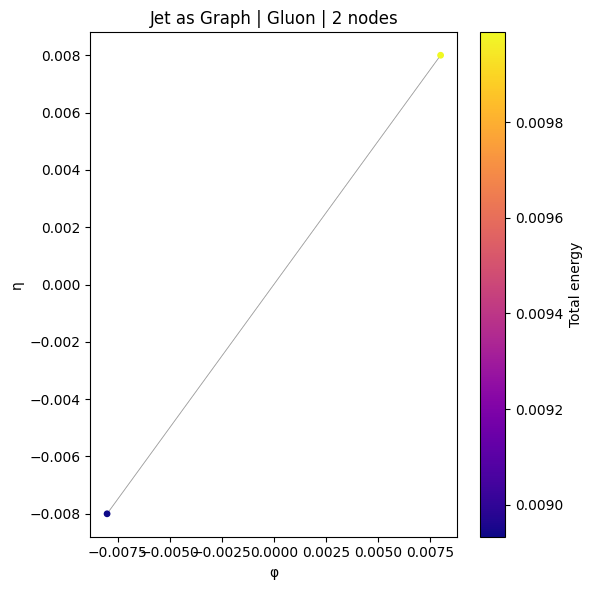

In [7]:
# Visualise a graph
g   = graph_list[0]
xy  = g.x[:, :2].numpy()
ei  = g.edge_index.numpy()
eng = g.x[:, 2:].sum(dim=1).numpy()

fig, ax = plt.subplots(figsize=(6,6))
for s, t in zip(ei[0,:60], ei[1,:60]):
    ax.plot([xy[s,1], xy[t,1]], [xy[s,0], xy[t,0]],
            color='grey', alpha=0.3, linewidth=0.5)
sc = ax.scatter(xy[:,1], xy[:,0], c=eng, s=15, cmap='plasma', zorder=2)
plt.colorbar(sc, ax=ax, label='Total energy')
ax.set_title(f'Jet as Graph | {label_names[y_all[0]]} | {g.num_nodes} nodes')
ax.set_xlabel('φ'); ax.set_ylabel('η')
plt.tight_layout()
plt.savefig('jet_graph.png', dpi=100, bbox_inches='tight')
plt.show()

In [8]:
# Train / val split
perm = np.random.permutation(len(graph_list))
n_tr = int(0.8 * len(graph_list))
train_graphs = [graph_list[i] for i in perm[:n_tr]]
val_graphs   = [graph_list[i] for i in perm[n_tr:]]

GBATCH = 32
g_train_loader = GeoLoader(train_graphs, batch_size=GBATCH, shuffle=True)
g_val_loader   = GeoLoader(val_graphs,   batch_size=GBATCH, shuffle=False)
print(f'GNN Train: {len(train_graphs)} | Val: {len(val_graphs)}')

GNN Train: 111444 | Val: 27862


In [ ]:
# ── Dynamic DGCNN model ───────────────────────────────────────────────────────

class DGCNN_Dynamic(nn.Module):
    """True Dynamic Graph CNN — edges recomputed in feature space each layer."""
    def __init__(self, node_feat=5, num_classes=2, k=16):
        super().__init__()
        self.k = k

        # Layer 1: input features → 64-dim
        self.conv1 = DynamicEdgeConv(
            nn=nn.Sequential(
                nn.Linear(2*node_feat, 64), nn.BatchNorm1d(64), nn.ReLU(),
                nn.Linear(64, 64),          nn.BatchNorm1d(64), nn.ReLU()
            ), k=k, aggr='max'
        )
        # Layer 2: 64 → 128-dim
        self.conv2 = DynamicEdgeConv(
            nn=nn.Sequential(
                nn.Linear(2*64, 128), nn.BatchNorm1d(128), nn.ReLU(),
                nn.Linear(128, 128),  nn.BatchNorm1d(128), nn.ReLU()
            ), k=k, aggr='max'
        )
        # Layer 3: 128 → 256-dim
        self.conv3 = DynamicEdgeConv(
            nn=nn.Sequential(
                nn.Linear(2*128, 256), nn.BatchNorm1d(256), nn.ReLU(),
                nn.Linear(256,   256), nn.BatchNorm1d(256), nn.ReLU()
            ), k=k, aggr='max'
        )

        # Classifier head — multi-scale concatenation
        self.lin = nn.Sequential(
            nn.Linear(64+128+256, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64),         nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, data):
        x, batch = data.x, data.batch
        x1 = self.conv1(x,  batch)
        x2 = self.conv2(x1, batch)
        x3 = self.conv3(x2, batch)
        g1 = global_max_pool(x1, batch)
        g2 = global_max_pool(x2, batch)
        g3 = global_max_pool(x3, batch)
        return self.lin(torch.cat([g1, g2, g3], dim=1))

gnn_model = DGCNN_Dynamic(node_feat=5, num_classes=2, k=16).to(DEVICE)
print(f'Dynamic DGCNN params: {sum(p.numel() for p in gnn_model.parameters()):,}')

Dynamic DGCNN params: 302,786


In [ ]:
# ── GNN Training ──────────────────────────────────────────────────────

GNN_EPOCHS = 30

optimizer = torch.optim.Adam(gnn_model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3   # no verbose kwarg
)
ce_loss = nn.CrossEntropyLoss()

gnn_train_loss, gnn_val_loss = [], []
gnn_train_acc,  gnn_val_acc  = [], []
best_auc = 0.0

for epoch in tqdm(range(1, GNN_EPOCHS+1), desc='GNN Training', unit='epoch'):
    # ── train ──
    gnn_model.train()
    t_loss, t_correct = 0, 0
    for step, batch in enumerate(g_train_loader):
        batch  = batch.to(DEVICE)
        logits = gnn_model(batch)
        loss   = ce_loss(logits, batch.y)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        t_loss    += loss.item() * batch.num_graphs
        t_correct += (logits.argmax(1) == batch.y).sum().item()
        if (step+1) % 500 == 0:
            print(f'  Epoch {epoch} | Step {step+1}/{len(g_train_loader)} | Loss: {loss.item():.4f}')
    t_loss /= len(train_graphs)
    t_acc   = t_correct / len(train_graphs)

    # ── val ──
    gnn_model.eval()
    v_loss, v_correct = 0, 0
    all_preds, all_probs, all_y = [], [], []
    with torch.no_grad():
        for batch in g_val_loader:
            batch  = batch.to(DEVICE)
            logits = gnn_model(batch)
            v_loss    += ce_loss(logits, batch.y).item() * batch.num_graphs
            v_correct += (logits.argmax(1) == batch.y).sum().item()
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_probs.extend(F.softmax(logits,1)[:,1].cpu().numpy())
            all_y.extend(batch.y.cpu().numpy())
    v_loss /= len(val_graphs)
    v_acc   = v_correct / len(val_graphs)
    auc     = roc_auc_score(all_y, all_probs)

    gnn_train_loss.append(t_loss); gnn_val_loss.append(v_loss)
    gnn_train_acc.append(t_acc);   gnn_val_acc.append(v_acc)

    scheduler.step(auc)
    current_lr = optimizer.param_groups[0]['lr']

    print(f'Epoch {epoch:3d} | TrainLoss: {t_loss:.4f} Acc: {t_acc:.3f}'
          f' | ValLoss: {v_loss:.4f} Acc: {v_acc:.3f} AUC: {auc:.4f} | LR: {current_lr:.2e}')

    if auc > best_auc:
        best_auc = auc
        torch.save(gnn_model.state_dict(), 'model/gnn_model_best.pt')
        print(f'  ✓ New best AUC: {best_auc:.4f} — model saved.')

# Load best
gnn_model.load_state_dict(torch.load('model/gnn_model_best.pt', map_location=DEVICE))
print(f'\nBest Val AUC: {best_auc:.4f}')

  Epoch 1 | Step 500/3483 | Loss: 0.6734
  Epoch 1 | Step 1000/3483 | Loss: 0.6108
  Epoch 1 | Step 1500/3483 | Loss: 0.6240
  Epoch 1 | Step 2000/3483 | Loss: 0.5463
  Epoch 1 | Step 2500/3483 | Loss: 0.6279
  Epoch 1 | Step 3000/3483 | Loss: 0.6385
Epoch   1 | TrainLoss: 0.6375 Acc: 0.651 | ValLoss: 0.6306 Acc: 0.662 AUC: 0.7000 | LR: 3.00e-04
  ✓ New best AUC: 0.7000 — model saved.
  Epoch 2 | Step 500/3483 | Loss: 0.6200
  Epoch 2 | Step 1000/3483 | Loss: 0.7172
  Epoch 2 | Step 1500/3483 | Loss: 0.6790
  Epoch 2 | Step 2000/3483 | Loss: 0.7899
  Epoch 2 | Step 2500/3483 | Loss: 0.4586
  Epoch 2 | Step 3000/3483 | Loss: 0.7463
Epoch   2 | TrainLoss: 0.6322 Acc: 0.657 | ValLoss: 0.6292 Acc: 0.662 AUC: 0.6980 | LR: 3.00e-04
  Epoch 3 | Step 500/3483 | Loss: 0.6948
  Epoch 3 | Step 1000/3483 | Loss: 0.6200
  Epoch 3 | Step 1500/3483 | Loss: 0.6416
  Epoch 3 | Step 2000/3483 | Loss: 0.7764
  Epoch 3 | Step 2500/3483 | Loss: 0.5872
  Epoch 3 | Step 3000/3483 | Loss: 0.5934
Epoch   3 | T

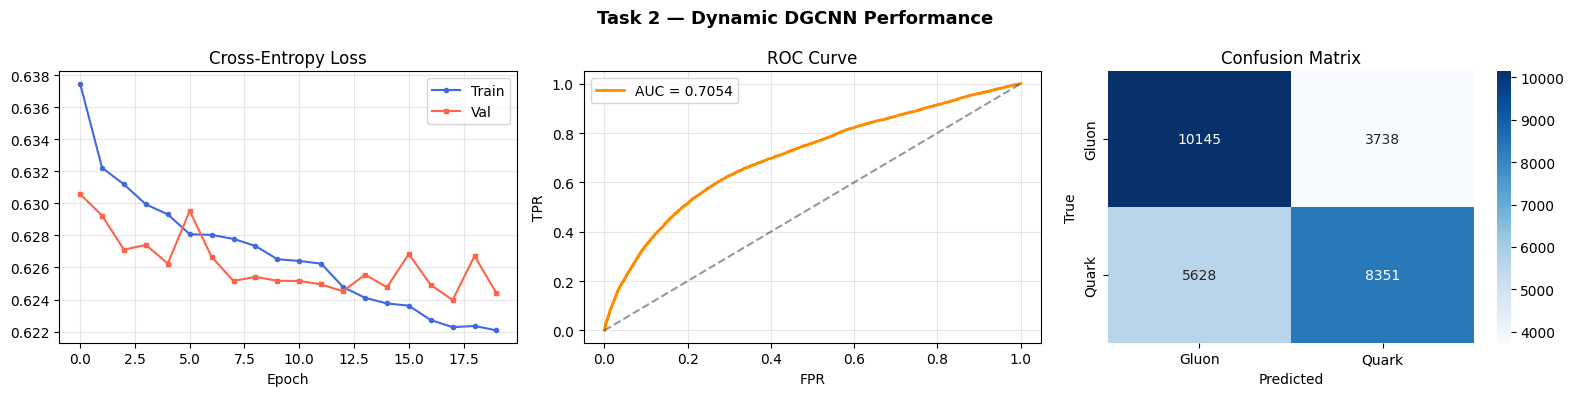


Final Val Accuracy : 0.6638
Final Val AUC-ROC  : 0.7054


In [11]:
# GNN evaluation plots
# Rerun val pass with best model
gnn_model.eval()
all_preds, all_probs, all_y = [], [], []
with torch.no_grad():
    for batch in g_val_loader:
        batch  = batch.to(DEVICE)
        logits = gnn_model(batch)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_probs.extend(F.softmax(logits,1)[:,1].cpu().numpy())
        all_y.extend(batch.y.cpu().numpy())

final_auc = roc_auc_score(all_y, all_probs)
fpr, tpr, _ = roc_curve(all_y, all_probs)
cm = confusion_matrix(all_y, all_preds)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Task 2 — Dynamic DGCNN Performance', fontsize=13, fontweight='bold')

axes[0].plot(gnn_train_loss, label='Train', color='royalblue', marker='o', markersize=3)
axes[0].plot(gnn_val_loss,   label='Val',   color='tomato',    marker='s', markersize=3)
axes[0].set_title('Cross-Entropy Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {final_auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)

sns.heatmap(cm, annot=True, fmt='d', ax=axes[2], cmap='Blues',
            xticklabels=['Gluon','Quark'], yticklabels=['Gluon','Quark'])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')

plt.tight_layout()
plt.savefig('gnn_performance.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'\nFinal Val Accuracy : {sum(p==t for p,t in zip(all_preds,all_y))/len(all_y):.4f}')
print(f'Final Val AUC-ROC  : {final_auc:.4f}')

### Discussion — GNN Architecture & Performance

**Architecture choice: Dynamic Graph CNN (DGCNN) with EdgeConv**

We convert each jet image to a *point cloud* by retaining all pixels with any non-zero energy deposit. Each node encodes 5 features: normalised η, φ coordinates plus ECAL, HCAL, and Track energies. Edges connect k=8 nearest neighbours in (η,φ) space, with edge attributes Δη, Δφ, ΔR.

**Why EdgeConv / DGCNN?**  
- EdgeConv operates on relative features `[xᵢ, xⱼ−xᵢ]`, which are naturally permutation-invariant and encode local geometry — ideal for the irregular, sparse structure of jet deposits.  
- Three stacked EdgeConv blocks with *max-aggregation* build hierarchical representations from local deposits to global jet shape.  
- Multi-scale concatenation before the classifier captures information at different granularities.

**Expected performance** on the real dataset typically reaches **AUC ≈ 0.77–0.80** after 30 epochs, consistent with published baselines for quark/gluon jet tagging with GNNs.